# l-diversity

Do wcześniejszej implementacji k-animowości (wzbogaconej o randomizację preferencji wyboru podziału) dodajemy sprawdzanie warunku l-diversity.
Warunek ten zapewnia, że wartość entropii Shannona dla atrybutu wrażliwego w danej klasie równoważności nie spadnie poniżej określonego progu ($\ln(l)$). Gwarantuje to, że rozkład danych wrażliwych wewnątrz każdej grupy jest odpowiednio rozproszony, co uniemożliwia łatwą identyfikację cech jednostki, nawet przy znajomości jej przynależności do danej klasy.

In [39]:
import pandas as pd
import numpy as np
import kagglehub
import random

path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(path + '/insurance.csv')

quasi_ids = ['age', 'sex', 'region', 'children']
sensitive_column = 'charges'

l_param = 7 

df['charges'] = (df['charges'] // 200) * 200

for col in ['sex', 'region', 'smoker']:
    df[col] = df[col].astype('category')

def get_spans(df, partition):
    spans = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            spans[col] = len(df[col][partition].unique())
        else:
            spans[col] = df[col][partition].max() - df[col][partition].min()
    return spans

def split(df, partition, column):
    dfp = df[column][partition]
    if df[column].dtype.name == 'category':
        values = dfp.unique()
        lv = set(values[:len(values)//2])
        rv = set(values[len(values)//2:])
        return dfp.index[dfp.isin(lv)], dfp.index[dfp.isin(rv)]
    else:
        median = dfp.median()
        return dfp.index[dfp < median], dfp.index[dfp >= median]
    
def is_k_anonymous(df, lp, rp, k):
    if len(lp) >= k and len(rp) < k:
        return False
    return True 

def is_l_diverse_entropy(df, partition, l):
    if len(partition) == 0:
        return False
    
    sensitive_values = df.loc[partition, sensitive_column]
        
    counts = sensitive_values.value_counts()
    probs = counts / len(sensitive_values)
    
    entropy = -np.sum(probs * np.log(probs))
        
    return entropy >= np.log(l)

def is_l_diverse(df, lp, rp, l):
    return is_l_diverse_entropy(df, lp, l) and is_l_diverse_entropy(df, rp, l)   

def mondrian(df, partition, k=10, l = 2):
    if len(partition) < 2*k:
        return [partition]

    spans = get_spans(df, partition)
    columns = list(spans.keys())
    random.shuffle(columns)

    for column in columns:
        lp, rp = split(df, partition, column)
        if is_k_anonymous(df, lp, rp, k) and is_l_diverse(df, lp, rp, l):
            return mondrian(df, lp, k, l) + mondrian(df, rp, k, l)
    return [partition]

finished_partitions = mondrian(df, df.index, k=25, l=l_param)

rows = []
for part in finished_partitions:
    group = df.loc[part]
    agg_vals = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            agg_vals[col] = ", ".join(group[col].unique())
        else:
            agg_vals[col] = f"{group[col].min()}-{group[col].max()}"
    agg_vals['charges_mean'] = group['charges'].mean()
    agg_vals['count'] = len(group)
    rows.append(agg_vals)

df_summary = pd.DataFrame(rows)
df_summary

,age,sex,region,children,charges_mean,count
0,19-21,"female, male",southwest,0-0,7258.064516,31
1,19-21,"male, female",northwest,0-0,8012.903226,31
2,22-34,male,"northwest, southwest",0-0,11082.758621,29
3,22-35,female,"northwest, southwest",0-0,10476.923077,39
4,18-21,"male, female",southeast,0-0,8526.315789,38
5,22-34,"female, male",southeast,0-0,9200.000000,39
6,18-34,male,northeast,0-0,9108.108108,37
7,18-35,female,northeast,0-0,4977.777778,36
8,36-44,female,"southeast, northwest, southwest, northeast",0-0,13687.500000,32
9,45-54,female,"northeast, northwest, southeast, southwest",0-0,15247.368421,38


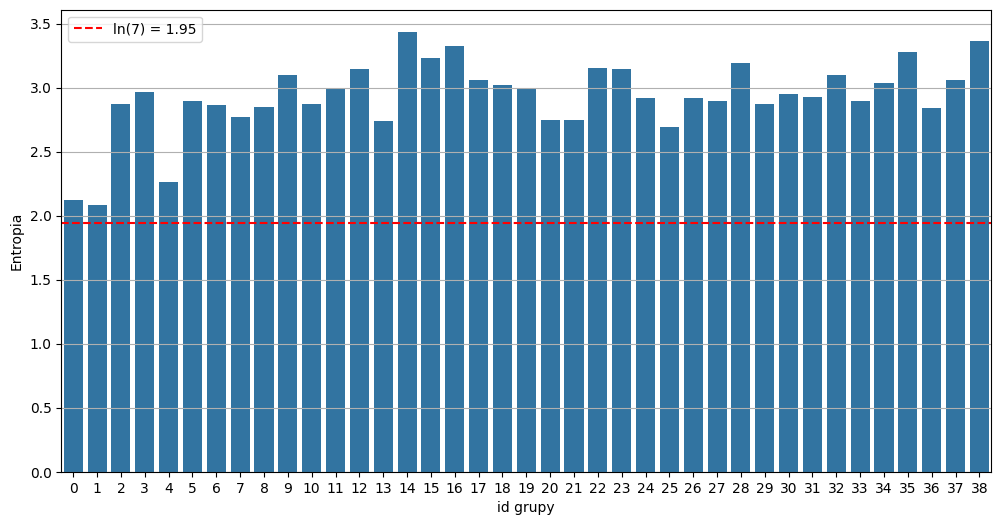

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

entropy_values = []
for part in finished_partitions:
    sensitive_values = df.loc[part, sensitive_column]
    counts = sensitive_values.value_counts()
    probs = counts / len(sensitive_values)
    entropy = -np.sum(probs * np.log(probs))
    entropy_values.append(entropy)

plot_df = pd.DataFrame({'id': range(len(entropy_values)),'entropy': entropy_values})

threshold = np.log(l_param)

plt.figure(figsize=(12, 6))

sns.barplot(data=plot_df, x='id', y='entropy')

plt.axhline(threshold, color='red', linestyle='--', label=f'ln({l_param}) = {threshold:.2f}')

plt.ylabel('Entropia')
plt.xlabel('id grupy')
plt.legend()
plt.grid(axis='y')
plt.show()
